# Gaussian Equivalence for Self-Attention Spectra — Minimal Reproduction

This notebook reproduces the spectral experiment from the post **Gaussian Equivalence for
Self-Attention Spectra** (AISTATS 2026 Batch). For a randomly-initialized softmax self-attention
matrix $A$ with the simplified setting $\ell=d=d_{qk}$ and input $X=I_d$, we verify three claims:

1. **Rank-one dominance** — $s_1(A)\to 1$ (equivalently $s_1(\sqrt d\,A)\to\sqrt d$): the largest
   singular value is entirely the uniform-averaging Perron mode $u_d u_d^\top$.
2. **Normalizer concentration** — the softmax row sums satisfy $Z_i\approx d\,e^{\beta^2/2}$, so the
   diagnostic $D_i=Z_i/(d\,e^{\beta^2/2})$ concentrates at $1$.
3. **Bulk spectral equivalence** — after removing the top few singular values, the squared
   singular-value *bulk* of $\sqrt d\,(A-u_du_d^\top)$ matches an explicit **Gaussian-equivalent
   linear model** $Y_{\text{lin}}^f=\beta\,\tfrac{S}{\sqrt d}+\sqrt{e^{\beta^2}-1-\beta^2}\,\tfrac{W}{\sqrt d}$.

We build a ladder of **seven models** interpolating from the true nonlinear attention to the linear
Gaussian equivalent, and compare their bulk spectra. Only `numpy` and `matplotlib` are required. The
printed $\theta$ statistics are exact and the diagnostics match the reference run (`runs/001`) to
within trial-to-trial Monte-Carlo fluctuation.

In [1]:
import math
import numpy as np
np.set_printoptions(precision=4, suppress=True)

## Configuration

The reference run used $d=\ell=d_{qk}=1000$, $\beta=1$, $10$ trials. Here we use $5$ trials for a
snappier run — this only smooths the Monte-Carlo histograms, it does not change the verified
quantities. The polynomial rung uses degree $n_d=\lceil c\log d/\log\log d\rceil$ with $c=2$.

In [2]:
SEED       = 0
D          = 1000          # d = ell = dqk  (identity input X = I_d)
BETA       = 1.0
NUM_TRIALS = 5             # reference used 10; 5 is enough and faster
REMOVE_TOP_K = 3           # drop the top-k squared singular values -> "bulk"
C_POLY     = 2.0           # polynomial degree parameter
THETA_MC_SAMPLES = 200_000 # Monte-Carlo samples for the polynomial theta statistics
HIST_BINS  = 120
HIST_RANGE = (0.0, 8.0)

REFERENCE_MODEL = "sqrt_d_A"
MODEL_ORDER = ["sqrt_d_A_perp", "Y", "Y_f", "Y_Q", "Y_Q_lin", "Y_f_lin"]
ALL_MODELS  = [REFERENCE_MODEL] + MODEL_ORDER

## Score matrix, softmax attention, and the uniform mode

With $X=I_d$ the score matrix reduces to $S=\tfrac{1}{\sqrt{d_{qk}}}W^Q(W^K)^\top$. The attention
matrix is the row-softmax $A=\mathrm{softmax}(\beta S)$, and the rank-one uniform baseline is
$u_d u_d^\top=\tfrac1d\mathbf 1\mathbf 1^\top$.

In [3]:
def generate_gaussian_weights(d, dqk, rng):
    Wq = rng.normal(0.0, 1.0, size=(d, dqk))
    Wk = rng.normal(0.0, 1.0, size=(d, dqk))
    W  = rng.normal(0.0, 1.0, size=(d, d))   # independent Gaussian for the linear models
    return Wq, Wk, W

def compute_score_matrix(Wq, Wk):
    dqk = Wq.shape[1]
    return (Wq @ Wk.T) / np.sqrt(dqk)         # X = I_d

def row_softmax(beta_S):
    z = beta_S - beta_S.max(axis=1, keepdims=True)   # numerically stable
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def uniform_mode(d):
    return np.full((d, d), 1.0 / d)

def row_normalizers(beta_S, beta):
    d = beta_S.shape[1]
    row_max = beta_S.max(axis=1, keepdims=True)
    Z = np.exp(row_max.squeeze(axis=1)) * np.exp(beta_S - row_max).sum(axis=1)
    D = Z / (d * np.exp(0.5 * beta ** 2))    # diagnostic: should -> 1
    return Z, D

## The nonlinearity $f$ and its Gaussian statistics

The deterministic-normalizer approximation $Z_i\approx d\,e^{\beta^2/2}$ gives
$A_{ij}\approx\tfrac1d\bigl(1+f(S_{ij})\bigr)$ with
$$f(x)=e^{\beta x-\beta^2/2}-1.$$
The two statistics that drive the Gaussian equivalence are, for $\chi\sim\mathcal N(0,1)$,
$$\theta_1=\mathbb E[f(\chi)^2]=e^{\beta^2}-1,\qquad \theta_2=(\mathbb E[f'(\chi)])^2=\beta^2,$$
and $\theta_1\ge\theta_2$ always.

In [4]:
def f_of_S(S, beta):
    return np.exp(beta * S - 0.5 * beta ** 2) - 1.0

def theta_stats_f(beta):
    return math.exp(beta ** 2) - 1.0, beta ** 2   # (theta1, theta2), exact

## Polynomial (Taylor) approximation $Q_n$

The middle rung of the ladder replaces the exponential by a truncated Taylor polynomial
$P_n(x)=\sum_{k<n}x^k/k!$, centered so $\mathbb E[Q_n(\chi)]=0$:
$$Q_n(x)=e^{-\beta^2/2}\bigl(P_n(\beta x)-\mathbb E[P_n(\beta\chi)]\bigr).$$
Its own statistics $\theta_1^Q=\mathbb E[Q_n(\chi)^2]$ and $\theta_2^Q=(\mathbb E[Q_n'(\chi)])^2$ are
estimated by Monte-Carlo. The recommended degree is $n_d=\lceil c\log d/\log\log d\rceil$.

In [5]:
def poly_degree(d, c):
    log_d = math.log(d)
    return int(math.ceil(c * log_d / math.log(log_d)))

def taylor_exp_poly(X, n):
    X = np.asarray(X, dtype=float)
    out = np.ones_like(X); term = np.ones_like(X)
    for k in range(1, n):
        term = term * X / k
        out = out + term
    return out

def gaussian_moment(k):
    if k % 2 == 1:
        return 0.0
    r = k // 2
    return math.factorial(2 * r) / (2.0 ** r * math.factorial(r))

def expected_taylor_poly(beta, n):
    return sum((beta ** k / math.factorial(k)) * gaussian_moment(k) for k in range(n))

def Qn_of_S(S, beta, n):
    P   = taylor_exp_poly(beta * S, n)
    E_P = expected_taylor_poly(beta, n)
    return np.exp(-0.5 * beta ** 2) * (P - E_P)

def theta_stats_Q_montecarlo(beta, n, num_samples, rng):
    chi = rng.normal(0.0, 1.0, size=num_samples)
    Q = Qn_of_S(chi, beta, n)
    theta1_Q = float(np.mean(Q ** 2))
    Q_deriv  = np.exp(-0.5 * beta ** 2) * beta * taylor_exp_poly(beta * chi, n - 1)
    theta2_Q = float(np.mean(Q_deriv)) ** 2
    return theta1_Q, theta2_Q

## The Gaussian-equivalent linear model

Orthogonal (Stein) projection writes $f(\chi)\approx\sqrt{\theta_2}\,\chi+\sqrt{\theta_1-\theta_2}\,\eta$
with $\eta\perp\chi$. In matrix form this becomes the linear surrogate
$$Y_{\text{lin}}=\sqrt{\theta_2}\,\tfrac{S}{\sqrt d}+\sqrt{\theta_1-\theta_2}\,\tfrac{W}{\sqrt d},$$
and with the exact $f$-statistics ($\theta_1=e^{\beta^2}-1,\ \theta_2=\beta^2$) this is exactly
$Y_{\text{lin}}^f=\beta\,\tfrac{S}{\sqrt d}+\sqrt{e^{\beta^2}-1-\beta^2}\,\tfrac{W}{\sqrt d}$.

In [6]:
def gaussian_equivalent(S, W, theta1, theta2, d):
    residual_var = max(theta1 - theta2, 0.0)
    return np.sqrt(theta2) * S / np.sqrt(d) + np.sqrt(residual_var) * W / np.sqrt(d)

## The seven models

| # | name | definition | role |
|---|------|-----------|------|
| M0 | `sqrt_d_A` | $\sqrt d\,A$ | reference; keeps the rank-one outlier |
| M1 | `sqrt_d_A_perp` | $\sqrt d\,(A-u_du_d^\top)$ | cleanest target for the theorem |
| M2 | `Y` | $e^{\beta S}/(e^{\beta^2/2}\sqrt d)$ | deterministic-normalizer exponential |
| M3 | `Y_f` | $f(S)/\sqrt d$ | centered nonlinear model |
| M4 | `Y_Q` | $Q_n(S)/\sqrt d$ | polynomial (Taylor) approximation |
| M5 | `Y_Q_lin` | Gaussian-equivalent of $Q_n$ | with MC $\theta^Q$ |
| M6 | `Y_f_lin` | Gaussian-equivalent of $f$ | final theoretical model, exact $\theta$ |

In [7]:
def build_all_models(S, W, beta, d, poly_n, theta_f, theta_Q):
    beta_S = beta * S
    A = row_softmax(beta_S)
    _, D = row_normalizers(beta_S, beta)
    sqrt_d = np.sqrt(d)
    u = uniform_mode(d)
    theta1, theta2 = theta_f
    theta1_Q, theta2_Q = theta_Q
    models = {
        "sqrt_d_A":      sqrt_d * A,
        "sqrt_d_A_perp": sqrt_d * (A - u),
        "Y":             np.exp(beta_S) / (np.exp(0.5 * beta ** 2) * sqrt_d),
        "Y_f":           f_of_S(S, beta) / sqrt_d,
        "Y_Q":           Qn_of_S(S, beta, poly_n) / sqrt_d,
        "Y_Q_lin":       gaussian_equivalent(S, W, theta1_Q, theta2_Q, d),
        "Y_f_lin":       gaussian_equivalent(S, W, theta1, theta2, d),
    }
    return models, D, A

## Spectra and distance metrics

For the bulk comparison we drop the top-$k$ squared singular values, then compare histogram
densities on a common grid via the $L_1$ distance $\sum_b|h^{\text{ref}}_b-h_b|\,\Delta$.

In [8]:
def squared_singular_values(M):
    s = np.linalg.svd(M, compute_uv=False)
    return s ** 2

def bulk_values(s2, remove_top_k):
    return np.sort(s2)[::-1][remove_top_k:]

def histogram_density(values, bins, value_range):
    hist, edges = np.histogram(values, bins=bins, range=tuple(value_range), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return hist, centers, edges

def l1_hist_distance(h1, h2, bin_width):
    return float(np.sum(np.abs(h1 - h2)) * bin_width)

## Run the trials

Each trial draws fresh $W^Q,W^K,W$, builds all seven models, and records: the top singular values
of $A$ and $\sqrt d\,A$, the normalizer diagnostics $D_i$, and the bulk squared singular values of
every model.

In [9]:
rng = np.random.default_rng(SEED)
poly_n = poly_degree(D, C_POLY)
theta_f = theta_stats_f(BETA)
theta_Q = theta_stats_Q_montecarlo(BETA, poly_n, THETA_MC_SAMPLES, rng)
print(f"polynomial degree n_d = {poly_n}")

bulk = {name: [] for name in ALL_MODELS}     # concatenated bulk s^2 across trials
top_sq = {name: [] for name in ALL_MODELS}   # top-5 s^2 per trial (for the bar plot)
s1_A, s1_sqrt_d_A, D_all = [], [], []

for t in range(NUM_TRIALS):
    Wq, Wk, W = generate_gaussian_weights(D, D, rng)
    S = compute_score_matrix(Wq, Wk)
    models, Dvec, A = build_all_models(S, W, BETA, D, poly_n, theta_f, theta_Q)
    D_all.append(Dvec)
    sA = np.linalg.svd(A, compute_uv=False)
    s1_A.append(sA[0]); s1_sqrt_d_A.append(np.sqrt(D) * sA[0])
    for name in ALL_MODELS:
        s2 = squared_singular_values(models[name])
        bulk[name].append(bulk_values(s2, REMOVE_TOP_K))
        top_sq[name].append(np.sort(s2)[::-1][:5])

bulk   = {k: np.concatenate(v) for k, v in bulk.items()}
top_sq = {k: np.mean(np.vstack(v), axis=0) for k, v in top_sq.items()}
D_all  = np.concatenate(D_all)
print(f"done: {NUM_TRIALS} trials, d = {D}, beta = {BETA}")

polynomial degree n_d = 8


done: 5 trials, d = 1000, beta = 1.0


## Claim 1 & 2 — rank-one mode and normalizer concentration

In [10]:
print("theta statistics")
print(f"  theta1(f) = e^(b^2)-1 = {theta_f[0]:.6f}   (reference 1.718282)")
print(f"  theta2(f) = b^2       = {theta_f[1]:.6f}   (reference 1.000000)")
print(f"  theta1(Q) [MC]        = {theta_Q[0]:.6f}   (reference ~1.7047)")
print(f"  theta2(Q) [MC]        = {theta_Q[1]:.6f}   (reference ~0.9987)")
print()
print("rank-one Perron mode")
print(f"  mean s1(A)      = {np.mean(s1_A):.5f}   (-> 1)")
print(f"  mean s1(sqrt_d A) = {np.mean(s1_sqrt_d_A):.4f}  (-> sqrt(d) = {np.sqrt(D):.4f})")
print()
print("row-normalizer concentration  D_i = Z_i / (d e^{b^2/2})")
print(f"  mean = {D_all.mean():.6f}   std = {D_all.std():.6f}   max|D-1| = {np.max(np.abs(D_all-1)):.6f}")

theta statistics
  theta1(f) = e^(b^2)-1 = 1.718282   (reference 1.718282)
  theta2(f) = b^2       = 1.000000   (reference 1.000000)
  theta1(Q) [MC]        = 1.704709   (reference ~1.7047)
  theta2(Q) [MC]        = 0.998729   (reference ~0.9987)

rank-one Perron mode
  mean s1(A)      = 1.00109   (-> 1)
  mean s1(sqrt_d A) = 31.6573  (-> sqrt(d) = 31.6228)

row-normalizer concentration  D_i = Z_i / (d e^{b^2/2})
  mean = 0.999230   std = 0.046890   max|D-1| = 0.199203


## Claim 3 — bulk spectral equivalence

$L_1$ distance of each model's bulk squared-singular-value histogram to the cleanest reference
`sqrt_d_A_perp`. All non-reference models are small; `Y_Q` (polynomial) and `Y_f_lin` (the
Gaussian-equivalent target) are the closest matches — the residual is the expected finite-$d$ gap,
since the equivalence is asymptotic.

In [11]:
ref_h, centers, _ = histogram_density(bulk["sqrt_d_A_perp"], HIST_BINS, HIST_RANGE)
bin_width = centers[1] - centers[0]
print(f"{'model':>16}   L1 to sqrt_d_A_perp   top-1 s^2")
print("-" * 52)
for name in ALL_MODELS:
    h, _, _ = histogram_density(bulk[name], HIST_BINS, HIST_RANGE)
    l1 = l1_hist_distance(ref_h, h, bin_width)
    print(f"{name:>16}   {l1:>16.4f}   {top_sq[name][0]:>9.3f}")

           model   L1 to sqrt_d_A_perp   top-1 s^2
----------------------------------------------------
        sqrt_d_A             0.0286    1002.185
   sqrt_d_A_perp             0.0000      10.199
               Y             0.0482    1002.934
             Y_f             0.0492      11.675
             Y_Q             0.0512      10.383
         Y_Q_lin             0.0646       8.824
         Y_f_lin             0.0602       8.872


## Figure — top squared singular values

`sqrt_d_A` and `Y` carry the large rank-one outlier ($s_1^2\approx d\approx 1000$); every other
model has no outlier ($s_1^2\approx 10$), confirming the spike is purely the uniform mode.

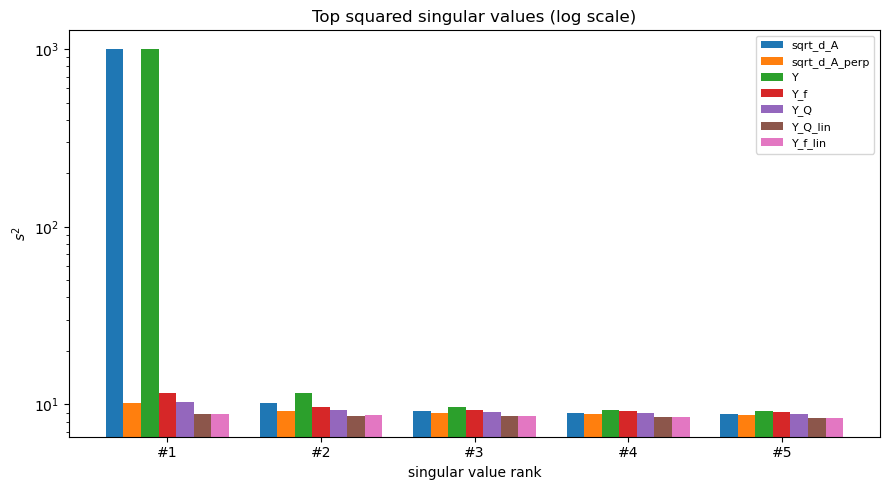

In [12]:
import matplotlib.pyplot as plt

names = ALL_MODELS
top_n = 5
x = np.arange(top_n); width = 0.8 / len(names)
fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(names):
    ax.bar(x + i * width, top_sq[name][:top_n], width=width, label=name)
ax.set_xticks(x + 0.4 - width / 2)
ax.set_xticklabels([f"#{k+1}" for k in range(top_n)])
ax.set_xlabel("singular value rank"); ax.set_ylabel(r"$s^2$")
ax.set_title("Top squared singular values (log scale)")
ax.set_yscale("log"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("top_singular_values.png", dpi=150); plt.show()

## Figure — row-normalizer concentration

Histogram of $D_i=Z_i/(d\,e^{\beta^2/2})$ over all rows and trials, tightly concentrated at $1$ —
this is what makes the deterministic-normalizer approximation valid.

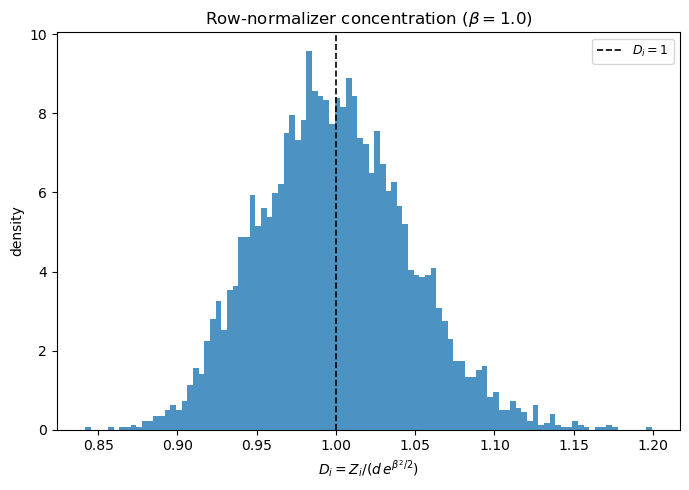

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(D_all, bins=100, density=True, color="C0", alpha=0.8)
ax.axvline(1.0, color="k", linestyle="--", linewidth=1.2, label=r"$D_i = 1$")
ax.set_xlabel(r"$D_i = Z_i / (d\, e^{\beta^2/2})$"); ax.set_ylabel("density")
ax.set_title(rf"Row-normalizer concentration ($\beta={BETA}$)")
ax.legend(fontsize=9); fig.tight_layout()
fig.savefig("normalizer_concentration.png", dpi=150); plt.show()

## Figure — sorted bulk squared singular values

The descending-sorted bulk curves of all models overlap closely (the reference `sqrt_d_A` is
dashed), the visual statement of bulk spectral equivalence.

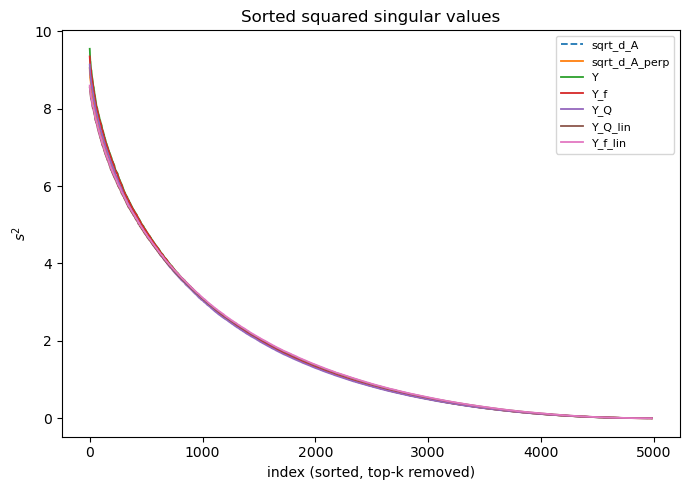

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in ALL_MODELS:
    vals = np.sort(bulk[name])[::-1]
    ax.plot(np.arange(len(vals)), vals, linewidth=1.3, label=name,
            linestyle="--" if name == REFERENCE_MODEL else "-")
ax.set_xlabel("index (sorted, top-k removed)"); ax.set_ylabel(r"$s^2$")
ax.set_title("Sorted squared singular values"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("sorted_squared_singular_values.png", dpi=150); plt.show()

**Takeaway.** A randomly-initialized softmax attention matrix is, spectrally, a rank-one
uniform-averaging mode plus a diffusive Gaussian-equivalent bulk. The three claims — $s_1(A)\to1$,
$Z_i\approx d\,e^{\beta^2/2}$, and bulk equivalence to $Y_{\text{lin}}^f$ — all hold at $d=1000$, and
the seven-model ladder shows the nonlinear attention and its linear Gaussian surrogate share the same
bulk law.